# Feature engineering

Продолжаем с того, на чём остановился `baseline_and_preprocessing.ipynb`, и проверяем пункты 14 до 17 из итоговой таблицы EDA. Модули с общим кодом ещё не вынесены, поэтому в разделе 1 заново собираем те решения из прошлого ноутбука, которые были приняты, без самих экспериментов и промежуточных сравнений, они уже разобраны там

Как и раньше, каждый шаг сравниваем по RMSE на логарифме цены в кросс-валидации, отдельно для Ridge и LightGBM, номер гипотезы в скобках это номер строки итоговой таблицы в `eda_and_hypotheses.ipynb`

## 1. Принятая предобработка из прошлого ноутбука

Повторяем шаги, которые в `baseline_and_preprocessing.ipynb` подтвердились или были приняты ради корректности данных: явные категории отсутствия объекта, исправление `MasVnrType`, удаление выбросов `Id` 524 и 1299, `log1p` для площадей без нулей, удаление скоррелированных и почти константных колонок, порядковое кодирование шести шкал качества

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.base import clone
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.model_selection import RepeatedKFold
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)

DATA_DIR = Path("../data")
TARGET = "SalePrice"
RANDOM_STATE = 42

train = pd.read_csv(DATA_DIR / "train.csv")
X = train.drop(columns=[TARGET, "Id"])
y = train[TARGET]

In [2]:
GARAGE_COLUMNS = ["GarageType", "GarageFinish", "GarageQual", "GarageCond"]
BASEMENT_COLUMNS = ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]
NO_OBJECT_COLUMNS = ["Alley", "Fence", "PoolQC", "FireplaceQu", "MiscFeature"] + GARAGE_COLUMNS + BASEMENT_COLUMNS
NO_ZERO_AREA_COLUMNS = ["LotFrontage", "LotArea", "1stFlrSF", "GrLivArea"]
DROPPED_COLUMNS = [
    "GarageArea", "GarageYrBlt", "TotRmsAbvGrd", "1stFlrSF",
    "Utilities", "Street", "Condition2", "RoofMatl", "Heating",
]
ORDINAL_QUALITY_COLUMNS = ["ExterQual", "BsmtQual", "BsmtCond", "HeatingQC", "KitchenQual", "FireplaceQu"]
QUALITY_ORDER = {"NA": 0, "Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5}
OUTLIER_IDS = [524, 1299]


def apply_accepted_preprocessing(df: pd.DataFrame, ids: pd.Series, masvnrtype_path: Path) -> pd.DataFrame:
    """Повторяет предобработку, принятую в baseline_and_preprocessing.ipynb

    Явные категории NA для отсутствующих объектов, исправление MasVnrType,
    log1p для площадей без нулей, удаление скоррелированных и почти
    константных колонок, порядковое кодирование шести шкал качества.
    Удаление выбросов делается отдельно, потому что оно трогает и y
    """
    result = df.copy()
    result[NO_OBJECT_COLUMNS] = result[NO_OBJECT_COLUMNS].fillna("NA")
    result["GarageYrBlt"] = result["GarageYrBlt"].fillna(0)

    raw_masvnrtype = pd.read_csv(masvnrtype_path, keep_default_na=False)["MasVnrType"]
    result["MasVnrType"] = raw_masvnrtype.replace({"NA": np.nan}).values

    result[NO_ZERO_AREA_COLUMNS] = np.log1p(result[NO_ZERO_AREA_COLUMNS])
    result = result.drop(columns=DROPPED_COLUMNS)

    for column in ORDINAL_QUALITY_COLUMNS:
        result[column] = result[column].map(QUALITY_ORDER)
    return result


X_base = apply_accepted_preprocessing(X, train["Id"], DATA_DIR / "train.csv")

keep = ~train["Id"].isin(OUTLIER_IDS)
X_base, y_base = X_base[keep].reset_index(drop=True), y[keep].reset_index(drop=True)

print(f"признаков: {X_base.shape[1]}, домов: {X_base.shape[0]}")

признаков: 70, домов: 1458


## 2. Схема валидации

Та же схема, что в прошлом ноутбуке: 5 фолдов с 3 повторами на фиксированном разбиении, RMSE на `log1p` цены, Ridge и LightGBM с одинаковой минимальной предобработкой по типу колонки

In [3]:
def rmse(log_true: pd.Series, log_pred: np.ndarray) -> float:
    """Среднеквадратичная ошибка между двумя массивами логарифмов цены"""
    return float(np.sqrt(np.mean((log_true - log_pred) ** 2)))


def cross_validate(model: Pipeline, X: pd.DataFrame, y: pd.Series) -> tuple[float, float]:
    """Считает RMSE на логарифме цены по повторной кросс-валидации

    Возвращает среднее и стандартное отклонение RMSE по всем фолдам
    """
    folds = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
    log_y = np.log1p(y)
    scores = []
    for fit_idx, valid_idx in folds.split(X):
        fitted = clone(model).fit(X.iloc[fit_idx], log_y.iloc[fit_idx])
        prediction = fitted.predict(X.iloc[valid_idx])
        scores.append(rmse(log_y.iloc[valid_idx], prediction))
    return float(np.mean(scores)), float(np.std(scores))


def build_preprocessor(scale: bool) -> ColumnTransformer:
    """Минимальная предобработка: медиана для чисел, мода и one-hot для категорий"""
    numeric_steps = [SimpleImputer(strategy="median")] + ([StandardScaler()] if scale else [])
    return ColumnTransformer(
        [
            ("numeric", make_pipeline(*numeric_steps), make_column_selector(dtype_include="number")),
            (
                "categorical",
                make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")),
                make_column_selector(dtype_exclude="number"),
            ),
        ]
    )


def build_models() -> dict[str, Pipeline]:
    """Собирает пайплайны Ridge и LightGBM с одинаковой минимальной предобработкой"""
    return {
        "Ridge": make_pipeline(build_preprocessor(scale=True), Ridge(alpha=10)),
        "LightGBM": make_pipeline(
            build_preprocessor(scale=False), LGBMRegressor(random_state=RANDOM_STATE, verbose=-1)
        ),
    }


results = []


def evaluate_models(experiment: str, X: pd.DataFrame, y: pd.Series) -> pd.DataFrame:
    """Оценивает обе модели на данных X, y и записывает результат в общий список results"""
    print(f"{experiment}: RMSE на логарифме цены по кросс-валидации")
    rows = []
    for model_name, model in build_models().items():
        rmse_value, std_value = cross_validate(model, X, y)
        rows.append({"experiment": experiment, "model": model_name, "rmse": rmse_value, "std": std_value})
    results.extend(rows)
    return pd.DataFrame(rows).set_index("model")[["rmse", "std"]]


def show_results() -> pd.DataFrame:
    """Собирает результаты всех экспериментов в таблицу RMSE по моделям

    Строки идут в порядке добавления экспериментов, pivot по умолчанию
    сортирует их по алфавиту, поэтому порядок восстанавливаем вручную
    """
    results_df = pd.DataFrame(results)
    experiment_order = results_df["experiment"].drop_duplicates()
    table = results_df.pivot(index="experiment", columns="model", values="rmse")
    return table.loc[experiment_order, ["Ridge", "LightGBM"]].round(4)

## 3. Бейзлайн этого ноутбука

Проверяем, что повторённая предобработка даёт тот же результат, что и в конце прошлого ноутбука

In [4]:
evaluate_models("1. Из предыдущего ноутбука", X_base, y_base)

1. Из предыдущего ноутбука: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.111718,0.006139
LightGBM,0.125650,0.006411


## 4. Составная площадь (гипотеза 14)

В EDA `TotalBsmtSF` и `GrLivArea` сильно связаны с ценой по отдельности, а `GrLivArea` уже равен сумме `1stFlrSF`, `2ndFlrSF` и `LowQualFinSF`. Гипотеза: их сумма, общая площадь дома, полезнее для модели, чем те же площади по отдельности

`GrLivArea` в `X_base` уже прошёл `log1p` на шаге 1, поэтому перед суммированием возвращаем его в исходный масштаб через `expm1`, складываем с `TotalBsmtSF`, который `log1p` не проходил, и снова берём `log1p` от суммы, как от обычной непрерывной площади без нулей

In [5]:
def add_total_area(df: pd.DataFrame) -> pd.DataFrame:
    """Заменяет TotalBsmtSF и GrLivArea на их сумму TotalSF

    GrLivArea уже прошёл log1p, поэтому сначала возвращается в доллары
    через expm1, а логарифм берётся заново от суммы
    """
    result = df.copy()
    raw_gr_liv_area = np.expm1(result["GrLivArea"])
    result["TotalSF"] = np.log1p(result["TotalBsmtSF"] + raw_gr_liv_area)
    return result.drop(columns=["TotalBsmtSF", "GrLivArea"])


X_total_area = add_total_area(X_base)
evaluate_models("2. TotalSF вместо TotalBsmtSF и GrLivArea", X_total_area, y_base)

2. TotalSF вместо TotalBsmtSF и GrLivArea: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.112403,0.005838
LightGBM,0.125928,0.006255


### Выводы: составная площадь

- Не подтвердилось для обеих моделей: RMSE вырос у Ridge с 0.1117 до 0.1124, у LightGBM с 0.1257 до 0.1259
- Похоже, что `TotalBsmtSF` и `GrLivArea` дают моделям больше сигнала по отдельности, чем их сумма: у подвала и жилой площади разная связь с ценой, а сумма эту разницу стирает
- Гипотезу отклоняем, `TotalBsmtSF` и `GrLivArea` остаются отдельными колонками, дальше используем `X_base`

## 5. Бинарные флаги для редких особенностей (гипотеза 15)

Бассейн есть у 7 домов из 1460, `MiscFeature` встречается у 54. `PoolArea`, `PoolQC`, `MiscFeature` и `MiscVal` почти целиком состоят из одного значения, отсутствия. Гипотеза: бинарный флаг наличия несёт для модели столько же, сколько площадь и качество, но с одной колонкой вместо четырёх

In [6]:
def replace_with_existence_flags(df: pd.DataFrame) -> pd.DataFrame:
    """Заменяет площадь и качество бассейна и прочих особенностей бинарными флагами наличия"""
    result = df.copy()
    result["HasPool"] = (result["PoolArea"] > 0).astype(int)
    result["HasMiscFeature"] = (result["MiscFeature"] != "NA").astype(int)
    return result.drop(columns=["PoolArea", "PoolQC", "MiscFeature", "MiscVal"])


X_existence_flags = replace_with_existence_flags(X_base)
evaluate_models("3. Флаги HasPool и HasMiscFeature", X_existence_flags, y_base)

3. Флаги HasPool и HasMiscFeature: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.111738,0.006053
LightGBM,0.125583,0.006592


### Выводы: бинарные флаги для редких особенностей

- У Ridge RMSE не изменился, 0.1117 и до, и после. У LightGBM небольшое улучшение, с 0.1257 до 0.1256
- Разница у LightGBM меньше стандартного отклонения между фолдами, около 0.006, то есть скорее в пределах шума, но и вреда нет
- Принимаем ради простоты: четыре колонки, `PoolArea`, `PoolQC`, `MiscFeature` и `MiscVal`, заменяются двумя бинарными флагами без потери в метрике, `X_existence_flags` идёт дальше

## 6. Флаг реконструкции (гипотеза 16)

В EDA флаг `IsRemodeled`, реконструкция позже 1950 и позже года постройки, оказался полезным сверх возраста дома: внутри каждой возрастной группы реконструированные дома дороже. Простое правило `YearRemodAdd != YearBuilt` вводит в заблуждение из-за того, что 1950 это технический минимум года реконструкции, а не настоящий год, поэтому условие с 1950 обязательно

In [7]:
def add_is_remodeled(df: pd.DataFrame) -> pd.DataFrame:
    """Добавляет флаг IsRemodeled, реконструкция позже постройки и позже 1950"""
    result = df.copy()
    result["IsRemodeled"] = ((result["YearRemodAdd"] > result["YearBuilt"]) & (result["YearRemodAdd"] > 1950)).astype(
        int
    )
    return result


X_remodeled = add_is_remodeled(X_existence_flags)
evaluate_models("4. Флаг IsRemodeled", X_remodeled, y_base)

4. Флаг IsRemodeled: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.111749,0.006045
LightGBM,0.125961,0.007318


### Выводы: флаг реконструкции

- У Ridge RMSE не изменился, 0.1117. У LightGBM RMSE слегка вырос, с 0.1256 до 0.1260, разница меньше стандартного отклонения между фолдами, около 0.007, то есть в пределах шума
- Метрика не подтверждает прирост, но в EDA флаг показывал устойчивую разницу в цене внутри каждой возрастной группы, а не просто корреляцию. Оставляем флаг ради этого содержательного основания, а не ради метрики, как раньше поступили с явными категориями пропусков и исправлением `MasVnrType`
- `X_remodeled` идёт дальше как основа для следующих шагов

## 7. Возраст дома и колонки продажи (гипотеза 17)

Две проверки из одной строки таблицы EDA. Первая: `YearBuilt` и производный от него возраст дома несут для модели одно и то же с точностью до знака, потому что все продажи укладываются в 2006 до 2010 годы, поэтому неважно, какой из двух признаков оставить. Вторая: `YrSold` и `MoSold` почти не связаны с ценой, проверяем их удаление

In [8]:
def replace_year_built_with_age(df: pd.DataFrame) -> pd.DataFrame:
    """Заменяет YearBuilt на HouseAge, разницу между годом продажи и годом постройки"""
    result = df.copy()
    result["HouseAge"] = result["YrSold"] - result["YearBuilt"]
    return result.drop(columns=["YearBuilt"])


X_house_age = replace_year_built_with_age(X_remodeled)
evaluate_models("5. HouseAge вместо YearBuilt", X_house_age, y_base)

5. HouseAge вместо YearBuilt: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.111749,0.006046
LightGBM,0.125171,0.006883


### Выводы: YearBuilt или HouseAge

- У Ridge RMSE не изменился, 0.1117, ожидаемо: `HouseAge` это почти линейная замена `YearBuilt`, а линейная модель не чувствительна к сдвигу шкалы
- У LightGBM RMSE упал с 0.1260 до 0.1252, это заметнее, чем предыдущие шаги. `HouseAge` не строго равен `YearBuilt` со знаком минус, потому что вычитается ещё и `YrSold`, который у разных домов разный, поэтому для дерева это не совсем тот же признак, и в этот раз замена помогла
- Заменяем `YearBuilt` на `HouseAge`, `X_house_age` идёт дальше как основа для следующих шагов

In [9]:
X_no_sale_dates = X_house_age.drop(columns=["YrSold", "MoSold"])
evaluate_models("6. Без YrSold и MoSold", X_no_sale_dates, y_base)

6. Без YrSold и MoSold: RMSE на логарифме цены по кросс-валидации


,rmse,std
model,,
Ridge,0.111652,0.006033
LightGBM,0.125567,0.006384


### Выводы: YrSold и MoSold

- У Ridge RMSE почти не изменился, 0.1117. У LightGBM RMSE вырос с 0.1252 до 0.1256, разница меньше стандартного отклонения между фолдами, около 0.006, но направление устойчиво отрицательное
- В EDA `YrSold` и `MoSold` почти не связаны с ценой напрямую, но, видимо, дают дереву дополнительные точки разбиения в сочетании с другими признаками, раз их удаление не помогает
- Гипотезу отклоняем, `YrSold` и `MoSold` остаются, `X_house_age` остаётся финальным набором признаков этого ноутбука

## Итоги ноутбука

Проверили пункты 14 до 17 из итоговой таблицы EDA. Из четырёх идей приняли три:

- бинарные флаги `HasPool` и `HasMiscFeature` вместо площади и качества редких особенностей, гипотеза 15, небольшое улучшение у LightGBM
- флаг `IsRemodeled`, гипотеза 16, метрика не подтверждает, но оставляем ради содержательного основания из EDA
- `HouseAge` вместо `YearBuilt`, гипотеза 17 частично, заметное улучшение у LightGBM

Отклонили составную площадь `TotalSF`, гипотеза 14, и удаление `YrSold` с `MoSold`, гипотеза 17 частично, в обоих случаях метрика становилась хуже

Путь метрики от бейзлайна этого ноутбука до финального набора признаков: у Ridge RMSE почти не изменился, 0.1117 в начале и в конце, у LightGBM упал с 0.1257 до 0.1256. Feature engineering здесь дал намного меньше, чем предобработка в прошлом ноутбуке, самый весомый вклад внёс `HouseAge`, а не новые составные признаки

Финальный набор для следующих ноутбуков: `X_house_age` и `y_base`

In [10]:
show_results()

model,Ridge,LightGBM
experiment,,
1. Из предыдущего ноутбука,0.1117,0.1257
2. TotalSF вместо TotalBsmtSF и GrLivArea,0.1124,0.1259
3. Флаги HasPool и HasMiscFeature,0.1117,0.1256
4. Флаг IsRemodeled,0.1117,0.1260
5. HouseAge вместо YearBuilt,0.1117,0.1252
6. Без YrSold и MoSold,0.1117,0.1256


### График изменения RMSE по экспериментам

6 точек, бейзлайн этого ноутбука и 5 экспериментов из таблицы выше, отдельно для Ridge и LightGBM

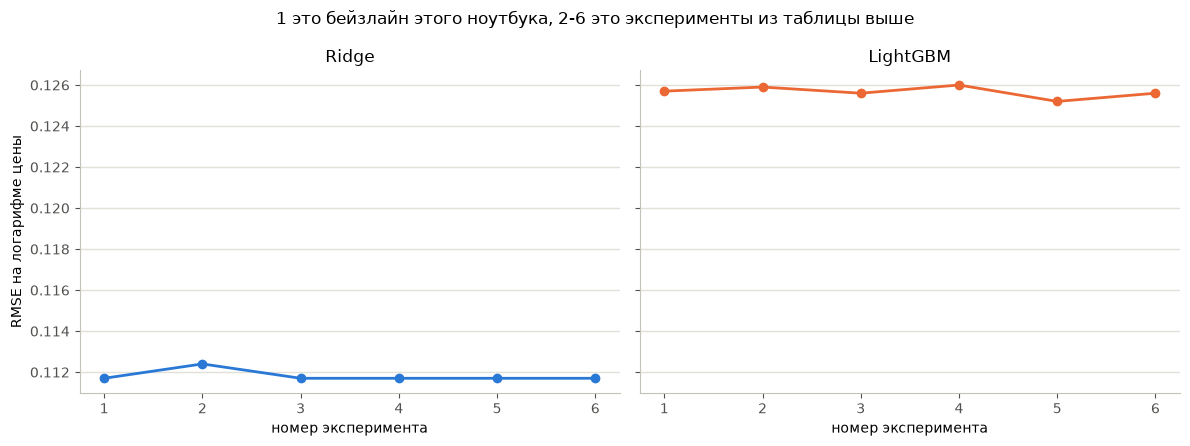

In [11]:
def plot_rmse_progress(results_table: pd.DataFrame, title: str) -> None:
    """Строит график RMSE по всем экспериментам ноутбука отдельно для Ridge и LightGBM

    Подписи по оси X это номер эксперимента из results_table
    """
    labels = [experiment.split(".")[0] for experiment in results_table.index]
    colors = {"Ridge": "#2a78d6", "LightGBM": "#eb6834"}

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
    for ax, model_name in zip(axes, ["Ridge", "LightGBM"]):
        ax.plot(
            labels,
            results_table[model_name].tolist(),
            color=colors[model_name],
            linewidth=2,
            marker="o",
            markersize=6,
        )
        ax.set_title(model_name)
        ax.set_xlabel("номер эксперимента")
        ax.grid(axis="y", color="#e1e0d9", linewidth=1)
        ax.spines[["top", "right"]].set_visible(False)
        ax.spines[["left", "bottom"]].set_color("#c3c2b7")
        ax.tick_params(colors="#52514e")

    axes[0].set_ylabel("RMSE на логарифме цены")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


plot_rmse_progress(show_results(), "1 это бейзлайн этого ноутбука, 2-6 это эксперименты из таблицы выше")

Гипотеза 14, точка 2, единственная, где обе модели становятся хуже бейзлайна. Дальше LightGBM колеблется заметнее Ridge, у которого линия почти горизонтальна: линейная модель одинаково спокойно принимает все эти изменения признаков, а дерево реагирует на каждое